# Noise Mitigation techniques with Iris Dataset
## Part 1: Variational Quantum Classifier (VQC) with Data Reuploading

**Architecture:**
- Encoding: `AngleEmbedding` (RY rotations)
- Ansatz: `StronglyEntanglingLayers`
- Strategy: Data Reuploading (embedding + ansatz repeated `n_layers` times)
- Classification: 1-vs-All × 3 (one per Iris class)

**Backends:**
- Simulator: `default.qubit` (PennyLane) — exact statevector, no shots
- Noisy Simulator: `qiskit.aer` with `NoiseModel.from_backend(ibm_marrakesh)` — 512 shots
- Optimisers: Adam (clean training) · SPSA (noisy training — hardware-compatible)

**Evaluation conditions:**
1. `sim_weights → sim_eval`    — train & test on perfect simulator (upper bound)
2. `sim_weights → noisy_eval`  — perfect weights, noisy evaluation
3. `noisy_weights → noisy_eval`— end-to-end noisy (realistic hardware scenario)

**Classical baseline:**
- SVM (RBF kernel) trained & evaluated on the same splits

**Anti-noise techniques applied to condition 3:**
- REM  (Readout Error Mitigation) — applied first, as pre-processing layer
- ZNE  (Zero Noise Extrapolation) — global folding + Richardson
- Digital ZNE — gate folding + Linear
- REM + ZNE  — combined pipeline
- REM + Digital ZNE — combined pipeline
- PEC  (Probabilistic Error Cancellation)


## 1. Imports & Configuration

In [3]:
import os
import json
import pennylane as qml
from pennylane import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Circuit hyperparameters
N_QUBITS    = 4    # one qubit per Iris feature
N_LAYERS    = 5    # reuploading depth — deeper circuit → noise more impactful
N_FEATURES  = 4    # sepal/petal length & width
SHOTS_SIM   = None # exact statevector on default.qubit
SHOTS_HW    = 512  # finite shots for noisy Aer simulator

# Training hyperparameters
LEARNING_RATE = 0.05
N_EPOCHS      = 15
BATCH_SIZE    = 5

# For saving results of models
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

# IBM Quantum credentials (fill in before running)
IBM_TOKEN = "IBM Token"

CLASS_NAMES = ["setosa", "versicolor", "virginica"]
print(f"PennyLane version : {qml.__version__}")
print(f"N_LAYERS={N_LAYERS}  SHOTS_HW={SHOTS_HW}")


PennyLane version : 0.44.1
N_LAYERS=5  SHOTS_HW=512


In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer.noise import NoiseModel
from pennylane_qiskit import RemoteDevice
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=IBM_TOKEN
)
backends = service.backends(simulator=False, operational=True)
print([b.name for b in backends])

qiskit_runtime_service._discover_account:WARNING:2026-06-09 13:46:22,830: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-06-09 13:46:24,453: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: QML. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-09 13:46:24,454: Loading instance: QML, plan: open


['ibm_fez', 'ibm_marrakesh', 'ibm_kingston']


In [5]:
ibm_backend = service.backend("ibm_marrakesh")

qiskit_runtime_service.backends:WARNING:2026-06-09 13:46:26,231: Using instance: QML, plan: open


In [6]:
props   = ibm_backend.properties()

gate_names = set(gate.gate for gate in props.gates)
print("Available gates:", gate_names)

Available gates: {'sx', 'rz', 'rzz', 'measure', 'id', 'reset', 'x', 'rx', 'cz'}


In [7]:
def summarize_errors(errors, label):
    if not errors:
        print(f"{label}: no data")
        return
    arr          = np.array(errors)
    arr_filtered = arr[arr < 1.0]
    print(f"{label}:")
    print(f"  min           : {arr.min():.6f}")
    print(f"  max           : {arr.max():.6f}")
    print(f"  mean          : {arr.mean():.6f}")
    print(f"  mean (filtered): {arr_filtered.mean():.6f}  ({len(arr) - len(arr_filtered)} dead qubit(s) excluded)")

# Single-qubit gate errors (SX gate)
sx_errors = [
    param.value
    for gate in props.gates
    if gate.gate == 'sx'
    for param in gate.parameters
    if param.name == 'gate_error'
]

# Two-qubit gate errors (CZ gate)
tq_errors = [
    param.value
    for gate in props.gates
    if gate.gate == 'cz' and len(gate.qubits) == 2
    for param in gate.parameters
    if param.name == 'gate_error'
]

# Readout errors
ro_errors = [
    param.value
    for qubit in props.qubits
    for param in qubit
    if param.name == 'readout_error'
]

tq_filtered = [e for e in tq_errors if e < 1.0]

print("=" * 40)
summarize_errors(sx_errors, "Single-qubit gate errors (SX)")
print()
summarize_errors(tq_errors, "Two-qubit gate errors (CZ)")
print()
summarize_errors(ro_errors, "Readout errors")
print("=" * 40)

noise_level_PEC = np.mean(tq_filtered)
# print(f"\nSuggested noise_level for PEC : {noise_level_PEC}")

Single-qubit gate errors (SX):
  min           : 0.000096
  max           : 1.000000
  mean          : 0.026089
  mean (filtered): 0.000459  (4 dead qubit(s) excluded)

Two-qubit gate errors (CZ):
  min           : 0.001108
  max           : 1.000000
  mean          : 0.039792
  mean (filtered): 0.005902  (12 dead qubit(s) excluded)

Readout errors:
  min           : 0.002441
  max           : 0.490234
  mean          : 0.041038
  mean (filtered): 0.041038  (0 dead qubit(s) excluded)


## 2. Dataset 1-vs-All preparation

In [8]:
# Load & scale to [0, π] so features map cleanly onto RY rotation angles
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Map target integers to names for better visualization
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Dataset preview:")
print(df.head())

Dataset preview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


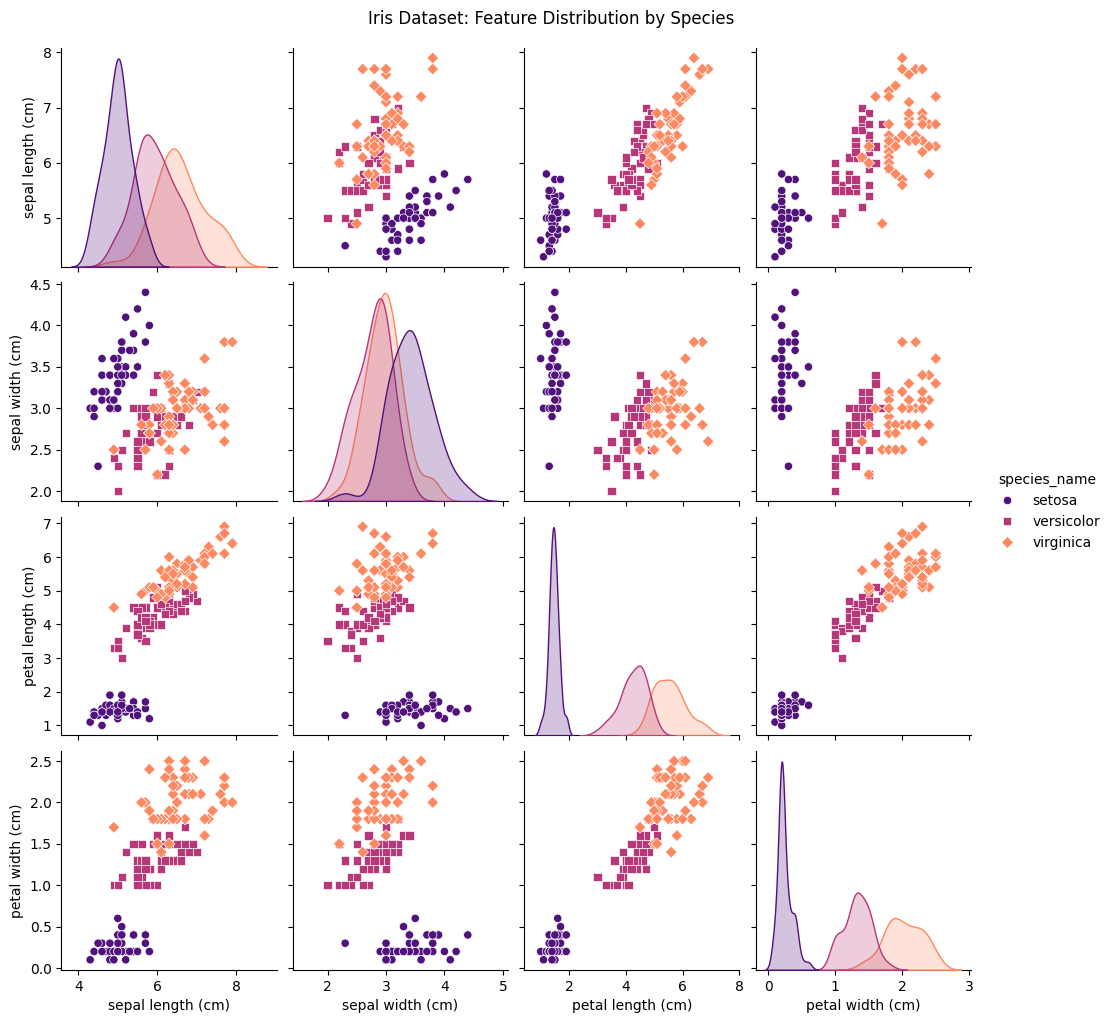

In [9]:
# Select only the feature columns for the pairplot (excluding 'species' and 'species_name')
feature_cols = iris.feature_names 

sns.pairplot(df[feature_cols + ['species_name']], hue='species_name', palette='magma', markers=["o", "s", "D"])
plt.suptitle("Iris Dataset: Feature Distribution by Species", y=1.02)
plt.show()

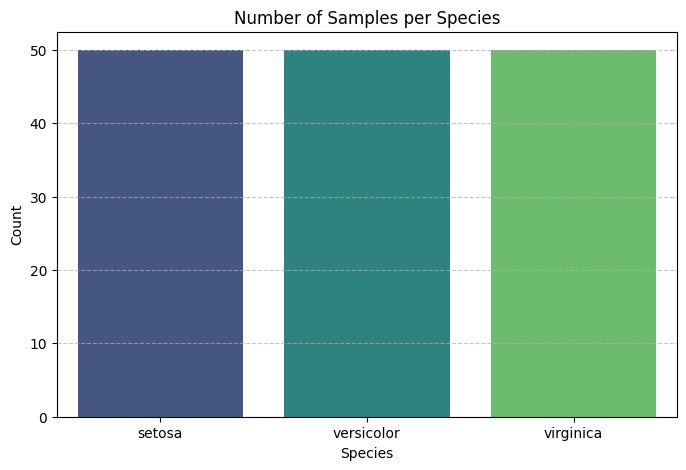

Class counts:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [10]:
# Count the number of samples for each species to ensure a balanced dataset
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='species_name', palette='viridis')

plt.title("Number of Samples per Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print counts for verification
print("Class counts:")
print(df['species_name'].value_counts())

In [11]:
X_raw = iris.data.astype(np.float64)
y_raw = iris.target

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X_raw)

# Build one binary dataset per class (1-vs-All)
def make_binary_dataset(X, y, positive_class):
    """
    Convert a multi-class target array into a binary {+1, -1} array.
    The chosen `positive_class` becomes +1; all others become -1.
    Labels are +1 / -1 to match the PauliZ expectation value output.
    """
    y_bin = np.where(y == positive_class, 1, -1).astype(np.float64)
    return X, y_bin

datasets = {}
for class_idx, class_name in enumerate(CLASS_NAMES):
    X_bin, y_bin = make_binary_dataset(X_scaled, y_raw, class_idx)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_bin, y_bin, test_size=0.2, random_state=SEED, stratify=y_bin
    )
    datasets[class_name] = {
        "X_train": X_tr, "y_train": y_tr,
        "X_test" : X_te, "y_test" : y_te,
    }
    pos = int((y_bin == 1).sum())
    print(f"  {class_name:12s} | +1: {pos:3d}  -1: {len(y_bin)-pos:3d} "
          f"| train: {len(y_tr)}  test: {len(y_te)}")

  setosa       | +1:  50  -1: 100 | train: 120  test: 30
  versicolor   | +1:  50  -1: 100 | train: 120  test: 30
  virginica    | +1:  50  -1: 100 | train: 120  test: 30


## 3. Reusable Circuit Function

The same architecture is instantiated for every (class, backend) combination:

Repeat N_LAYERS times  (data reuploading loop) 

AngleEmbedding(x)   — RY on 4 qubits 

StronglyEntanglingLayers(W_l)   

Measure ⟨Z₀⟩  ∈ (−1, +1)


In [12]:
def create_vqc(device_name, n_qubits=N_QUBITS, n_layers=N_LAYERS, **device_kwargs):
    """
    Factory that builds a Variational Quantum Classifier with Data Reuploading.

    The same circuit topology is shared across all 1-vs-All classifiers and
    across both the simulator and real-hardware backends — only the underlying
    PennyLane device changes.

    Architecture (per reuploading layer):
        AngleEmbedding(x)  →  StronglyEntanglingLayers(W_l)
    Repeated `n_layers` times, then measure ⟨Z₀⟩.
    """

    device = qml.device(device_name, wires=n_qubits, **device_kwargs)

    # Weight shape: one (n_qubits × 3) parameter block per reuploading layer
    weight_shape = qml.StronglyEntanglingLayers.shape(
        n_layers=n_layers, n_wires=n_qubits
    )

    @qml.qnode(device, diff_method="best") #With diff_method best it uses Parameter-Shift-Rule (perfect gradients)
    def circuit(inputs, weights):
        """
        Data-reuploading VQC circuit.

        Parameters
        ----------
        inputs  : array, shape (n_features,)
        weights : array, shape (n_layers, n_qubits, 3)
                  Trainable rotation angles for StronglyEntanglingLayers.

        Returns
        -------
        float  — expectation value ⟨Z₀⟩ ∈ (−1, +1)
        """
        for layer_idx in range(n_layers):
            # Encode classical data into quantum amplitudes 
            qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')

            # Trainable entangling ansatz
            # Each layer applies RZ/RY/RZ + CNOT entanglers across all qubits
            qml.StronglyEntanglingLayers(
                weights[layer_idx * (weight_shape[0] // n_layers) :
                        (layer_idx + 1) * (weight_shape[0] // n_layers)],
                wires=range(n_qubits)
            )

        # Measurement
        # ⟨Z₀⟩ → sign gives predicted class: +1 (positive) or -1 (negative)
        return qml.expval(qml.PauliZ(0))

    return circuit, weight_shape, device

In [13]:
def create_vqc_noisy(device_name, n_qubits=N_QUBITS, n_layers=N_LAYERS, **device_kwargs):
    device = qml.device(device_name, wires=n_qubits, **device_kwargs)
    weight_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)

    @qml.qnode(device)   # no diff_method — SPSA handles it externally, for faster compilation
    def circuit(inputs, weights):
        for layer_idx in range(n_layers):
            qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
            qml.StronglyEntanglingLayers(
                weights[layer_idx * (weight_shape[0] // n_layers) :
                        (layer_idx + 1) * (weight_shape[0] // n_layers)],
                wires=range(n_qubits)
            )
        return qml.expval(qml.PauliZ(0))

    return circuit, weight_shape, device

## 4. Instantiate All Circuits

| Variable | Backend | Class |
|---|---|---|
| `sim_setosa` | `default.qubit` | setosa |
| `sim_versicolor` | `default.qubit` | versicolor |
| `sim_virginica` | `default.qubit` | virginica |
| `hw_setosa` | `qiskit.aer` | setosa |
| `hw_versicolor` | `qiskit.aer` | versicolor |
| `hw_virginica` | `qiskit.aer` | virginica |

In [14]:
# Simulator circuits (exact statevector)
sim_setosa,     weight_shape, _ = create_vqc('default.qubit')
sim_versicolor, weight_shape, _ = create_vqc('default.qubit')
sim_virginica,  weight_shape, _ = create_vqc('default.qubit')

print(f"Simulator circuits ready — weight shape per model: {weight_shape}")

# Noisy Aer circuits (IBM noise model, 512 shots)
noise_model = NoiseModel.from_backend(ibm_backend)

hw_setosa, weight_shape, hw_dev = create_vqc_noisy(
    'qiskit.aer', shots=SHOTS_HW, backend='qasm_simulator', noise_model=noise_model
)
hw_versicolor, weight_shape, _ = create_vqc_noisy(
    'qiskit.aer', shots=SHOTS_HW, backend='qasm_simulator', noise_model=noise_model
)
hw_virginica, weight_shape, _ = create_vqc_noisy(
    'qiskit.aer', shots=SHOTS_HW, backend='qasm_simulator', noise_model=noise_model
)
print(f"Noisy simulator ready — noise model from: {ibm_backend.name}  shots={SHOTS_HW}")


Simulator circuits ready — weight shape per model: (5, 4, 3)
Noisy simulator ready — noise model from: ibm_marrakesh  shots=512


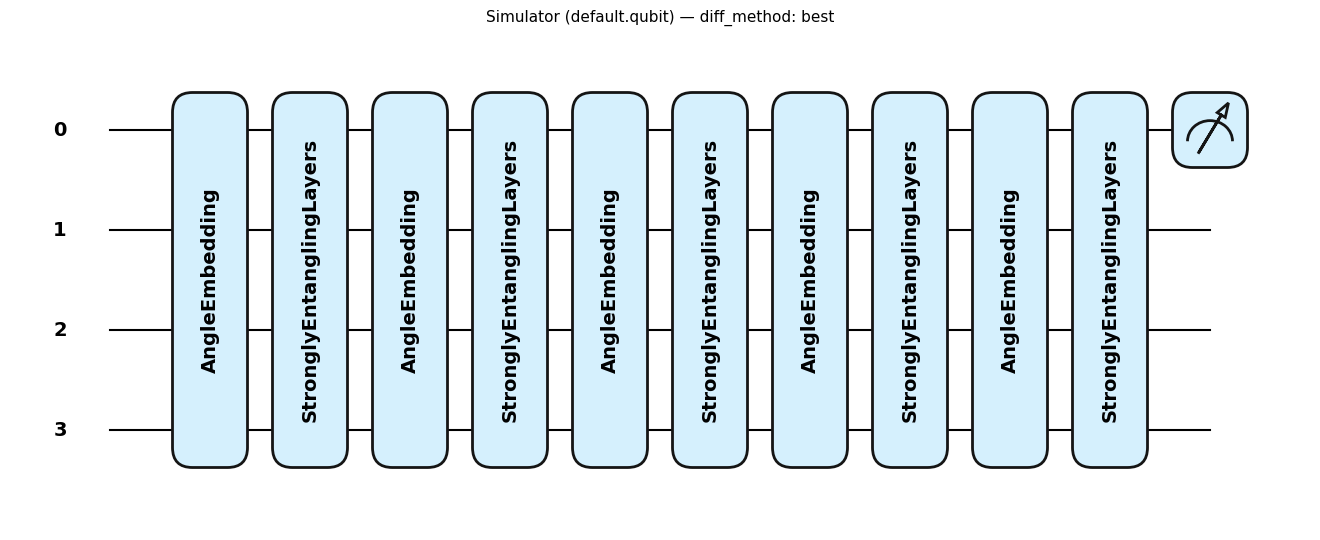

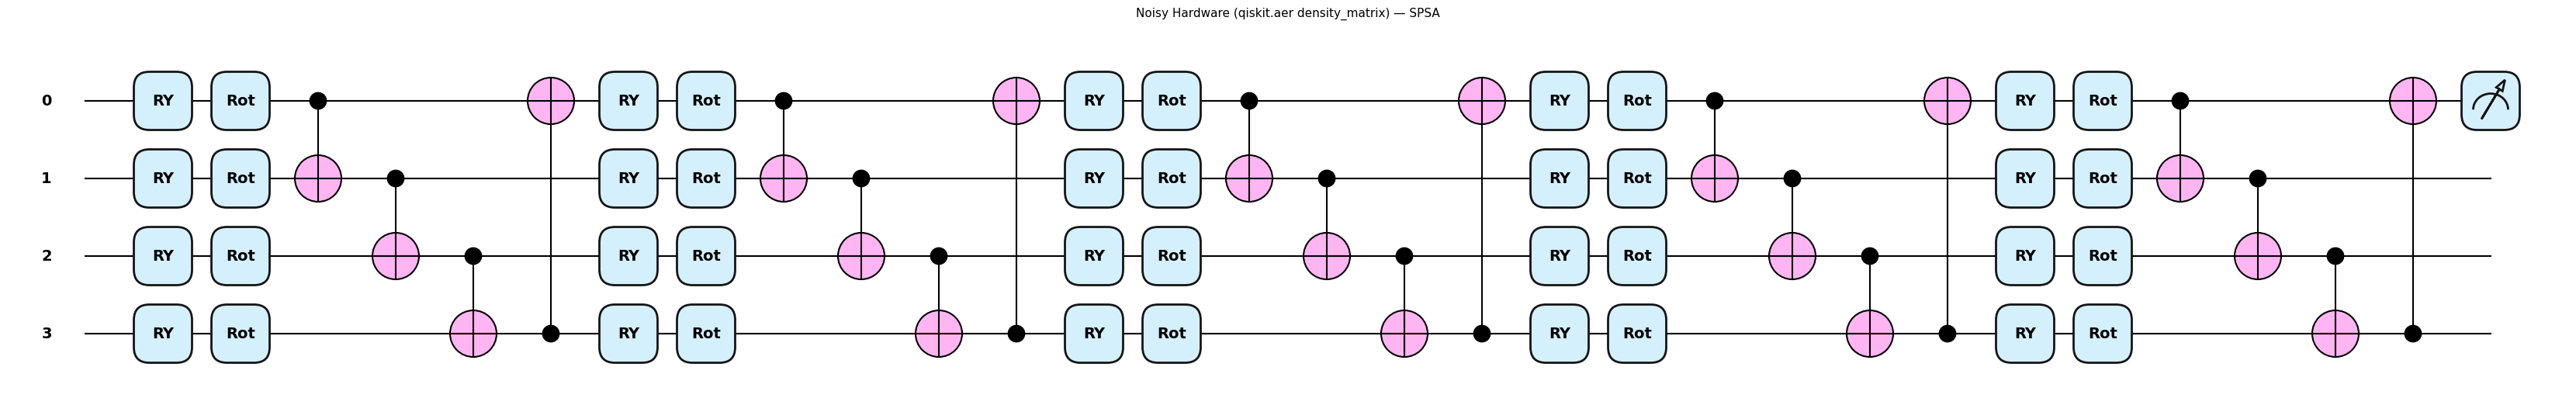

In [15]:
# Draw both circuit versions side by side
dummy_weights = np.zeros(weight_shape)
dummy_input   = np.zeros(N_FEATURES)

# Clean simulator circuit
_, ax = qml.draw_mpl(sim_setosa, decimals=None, style="pennylane")(dummy_input, dummy_weights)
ax.set_title("Simulator (default.qubit) — diff_method: best", fontsize=11)
plt.show()

# Noisy circuit
_, ax = qml.draw_mpl(hw_setosa, decimals=None, style="pennylane")(dummy_input, dummy_weights)
ax.set_title("Noisy Hardware (qiskit.aer density_matrix) — SPSA", fontsize=11)
plt.show()

## 5. Training Loop

In [16]:
def mse_loss(predictions, targets):
    """
    Mean squared error between ⟨Z⟩ predictions and {+1, -1} targets.
    Differentiable through PennyLane's autograd.
    """
    return np.mean((predictions - targets) ** 2)


def train_vqc(
    circuit, weight_shape, X_train, y_train,
    n_epochs=N_EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE, label=""
):
    """
    Train a VQC circuit using mini-batch gradient descent with the
    Adam optimiser from PennyLane's autograd backend.

    Parameters
    ----------
    circuit      : QNode returned by create_vqc()
    weight_shape : tuple  — shape of the trainable weight tensor
    X_train      : array, shape (n_samples, n_features)
    y_train      : array, shape (n_samples,)  — values in {+1, -1}
    n_epochs     : int   — number of full passes over training data
    lr           : float — Adam learning rate
    batch_size   : int   — samples per gradient step
    label        : str   — displayed in the progress printout

    Returns
    -------
    weights    : array  — optimised weight tensor
    loss_curve : list   — mean MSE loss recorded after each epoch
    """
    # Initialise weights near zero for stable early training
    weights = np.random.uniform(-np.pi, np.pi, weight_shape, requires_grad=True)
    opt     = qml.AdamOptimizer(stepsize=lr)
    loss_curve = []

    n_samples = len(X_train)

    for epoch in range(n_epochs):
        # Shuffle training data each epoch
        perm     = np.random.permutation(n_samples)
        X_shuf   = X_train[perm]
        y_shuf   = y_train[perm]
        epoch_losses = []

        for start in range(0, n_samples, batch_size):
            X_batch = X_shuf[start : start + batch_size]
            y_batch = y_shuf[start : start + batch_size]

            def batch_cost(w):
                # Vectorised forward pass over the mini-batch
                preds = np.array([circuit(x, w) for x in X_batch])
                return mse_loss(preds, y_batch)

            weights, loss_val = opt.step_and_cost(batch_cost, weights)
            epoch_losses.append(float(loss_val))

        mean_loss = float(np.mean(epoch_losses))
        loss_curve.append(mean_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  [{label}] epoch {epoch+1:3d}/{n_epochs}  loss: {mean_loss:.4f}")

    return weights, loss_curve

In [17]:
def train_vqc_noisy(circuit, weight_shape, X_train, y_train,
                    n_epochs=N_EPOCHS, label=""):
    weights = np.random.uniform(-np.pi, np.pi, weight_shape, requires_grad=True)
    # maxiter=1 → exactly 2 circuit calls per step, no internal loop
    opt = qml.SPSAOptimizer(maxiter=1)
    loss_curve = []

    for epoch in range(n_epochs):
        # Single cost evaluation over a small random subset (no batching loop)
        idx = np.random.choice(len(X_train), size=10, replace=False)
        X_sub = X_train[idx]
        y_sub = y_train[idx]

        def cost(w):
            preds = np.array([circuit(x, w) for x in X_sub])
            return mse_loss(preds, y_sub)

        weights, loss_val = opt.step_and_cost(cost, weights)
        loss_curve.append(float(loss_val))

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  [{label}] epoch {epoch+1:3d}/{n_epochs}  loss: {float(loss_val):.4f}")

    return weights, loss_curve

In [18]:
def save_results(results, prefix):
    """
    Save weights and loss curves to the models/ folder.
    weights    → models/{prefix}_{class_name}_weights.npy
    loss_curve → models/{prefix}_{class_name}_loss.json
    """
    for class_name, data in results.items():
        np.save(
            os.path.join(MODELS_DIR, f"{prefix}_{class_name}_weights.npy"),
            np.array(data["weights"])
        )
        with open(os.path.join(MODELS_DIR, f"{prefix}_{class_name}_loss.json"), "w") as f:
            json.dump(data["loss_curve"], f)
    print(f"Saved {len(results)} models with prefix '{prefix}' to {MODELS_DIR}/")


def load_results(prefix, class_names=CLASS_NAMES):
    """
    Load weights and loss curves from the models/ folder.
    Returns a dict with the same structure as sim_results / hw_results.
    """
    results = {}
    for class_name in class_names:
        w_path = os.path.join(MODELS_DIR, f"{prefix}_{class_name}_weights.npy")
        l_path = os.path.join(MODELS_DIR, f"{prefix}_{class_name}_loss.json")
        if not os.path.exists(w_path):
            raise FileNotFoundError(f"No saved weights found for {prefix}/{class_name} — train first.")
        weights = np.load(w_path)
        with open(l_path) as f:
            loss_curve = json.load(f)
        results[class_name] = {"weights": weights, "loss_curve": loss_curve}
    print(f"Loaded {len(results)} models with prefix '{prefix}' from {MODELS_DIR}/")
    return results

### 5.1 Train Simulator Models

In [19]:
SIM_PREFIX = "sim"
sim_results = {}
# Map class name → its simulator circuit
sim_circuits = {
    "setosa"    : sim_setosa,
    "versicolor": sim_versicolor,
    "virginica" : sim_virginica,
}

HW_PREFIX = "hw"
hw_results = {}
hw_circuits = {
    "setosa"    : hw_setosa,
    "versicolor": hw_versicolor,
    "virginica" : hw_virginica,
}

In [20]:
# Train or load: setosa
if os.path.exists(os.path.join(MODELS_DIR, f"{SIM_PREFIX}_setosa_weights.npy")):
    print("Setosa sim weights found — loading from disk.")
    sim_results["setosa"] = load_results(SIM_PREFIX, ["setosa"])["setosa"]
else:
    d = datasets["setosa"]
    weights, loss_curve = train_vqc(
        sim_circuits["setosa"], weight_shape,
        d["X_train"], d["y_train"], label="sim/setosa"
    )
    sim_results["setosa"] = {"weights": weights, "loss_curve": loss_curve}
    save_results({"setosa": sim_results["setosa"]}, SIM_PREFIX)

  [sim/setosa] epoch   1/15  loss: 0.3594
  [sim/setosa] epoch   5/15  loss: 0.0727
  [sim/setosa] epoch  10/15  loss: 0.0555
  [sim/setosa] epoch  15/15  loss: 0.0615
Saved 1 models with prefix 'sim' to models/


In [21]:
# Train or load: versicolor
if os.path.exists(os.path.join(MODELS_DIR, f"{SIM_PREFIX}_versicolor_weights.npy")):
    print("Versicolor sim weights found — loading from disk.")
    sim_results["versicolor"] = load_results(SIM_PREFIX, ["versicolor"])["versicolor"]
else:
    d = datasets["versicolor"]
    weights, loss_curve = train_vqc(
        sim_circuits["versicolor"], weight_shape,
        d["X_train"], d["y_train"], label="sim/versicolor"
    )
    sim_results["versicolor"] = {"weights": weights, "loss_curve": loss_curve}
    save_results({"versicolor": sim_results["versicolor"]}, SIM_PREFIX)

  [sim/versicolor] epoch   1/15  loss: 0.5469
  [sim/versicolor] epoch   5/15  loss: 0.2043
  [sim/versicolor] epoch  10/15  loss: 0.1769
  [sim/versicolor] epoch  15/15  loss: 0.1673
Saved 1 models with prefix 'sim' to models/


In [22]:
# Train or load: virginica
if os.path.exists(os.path.join(MODELS_DIR, f"{SIM_PREFIX}_virginica_weights.npy")):
    print("Virginica sim weights found — loading from disk.")
    sim_results["virginica"] = load_results(SIM_PREFIX, ["virginica"])["virginica"]
else:
    d = datasets["virginica"]
    weights, loss_curve = train_vqc(
        sim_circuits["virginica"], weight_shape,
        d["X_train"], d["y_train"], label="sim/virginica"
    )
    sim_results["virginica"] = {"weights": weights, "loss_curve": loss_curve}
    save_results({"virginica": sim_results["virginica"]}, SIM_PREFIX)

  [sim/virginica] epoch   1/15  loss: 0.5550
  [sim/virginica] epoch   5/15  loss: 0.2027
  [sim/virginica] epoch  10/15  loss: 0.1542
  [sim/virginica] epoch  15/15  loss: 0.1690
Saved 1 models with prefix 'sim' to models/


### 5.2 Train Hardware (Aer / IBM) Models

In [23]:
# Train or load: setosa (noisy SPSA)
if os.path.exists(os.path.join(MODELS_DIR, f"{HW_PREFIX}_setosa_weights.npy")):
    print("Setosa hw weights found — loading from disk.")
    hw_results["setosa"] = load_results(HW_PREFIX, ["setosa"])["setosa"]
else:
    d = datasets["setosa"]
    weights, loss_curve = train_vqc_noisy(
        hw_circuits["setosa"], weight_shape,
        d["X_train"], d["y_train"], label="hw/setosa"
    )
    hw_results["setosa"] = {"weights": weights, "loss_curve": loss_curve}
    save_results({"setosa": hw_results["setosa"]}, HW_PREFIX)


  [hw/setosa] epoch   1/15  loss: 1.3246
  [hw/setosa] epoch   5/15  loss: 1.0382
  [hw/setosa] epoch  10/15  loss: 1.0730
  [hw/setosa] epoch  15/15  loss: 0.9846
Saved 1 models with prefix 'hw' to models/


In [24]:
# Train or load: versicolor (noisy SPSA)
if os.path.exists(os.path.join(MODELS_DIR, f"{HW_PREFIX}_versicolor_weights.npy")):
    print("Versicolor hw weights found — loading from disk.")
    hw_results["versicolor"] = load_results(HW_PREFIX, ["versicolor"])["versicolor"]
else:
    d = datasets["versicolor"]
    weights, loss_curve = train_vqc_noisy(
        hw_circuits["versicolor"], weight_shape,
        d["X_train"], d["y_train"], label="hw/versicolor"
    )
    hw_results["versicolor"] = {"weights": weights, "loss_curve": loss_curve}
    save_results({"versicolor": hw_results["versicolor"]}, HW_PREFIX)


  [hw/versicolor] epoch   1/15  loss: 0.9726
  [hw/versicolor] epoch   5/15  loss: 0.9841
  [hw/versicolor] epoch  10/15  loss: 0.8110
  [hw/versicolor] epoch  15/15  loss: 0.8216
Saved 1 models with prefix 'hw' to models/


In [25]:
# Train or load: virginica (noisy SPSA)
if os.path.exists(os.path.join(MODELS_DIR, f"{HW_PREFIX}_virginica_weights.npy")):
    print("Virginica hw weights found — loading from disk.")
    hw_results["virginica"] = load_results(HW_PREFIX, ["virginica"])["virginica"]
else:
    d = datasets["virginica"]
    weights, loss_curve = train_vqc_noisy(
        hw_circuits["virginica"], weight_shape,
        d["X_train"], d["y_train"], label="hw/virginica"
    )
    hw_results["virginica"] = {"weights": weights, "loss_curve": loss_curve}
    save_results({"virginica": hw_results["virginica"]}, HW_PREFIX)


  [hw/virginica] epoch   1/15  loss: 1.1313
  [hw/virginica] epoch   5/15  loss: 0.7548
  [hw/virginica] epoch  10/15  loss: 0.8314
  [hw/virginica] epoch  15/15  loss: 0.9975
Saved 1 models with prefix 'hw' to models/


## 6. Evaluation

In [26]:
def predict_proba(circuit, weights, X):
    """
    Run the trained circuit over dataset X.
    Returns raw ⟨Z⟩ scores ∈ (−1, +1) — higher = more likely positive class.
    """
    return np.array([float(circuit(x, weights)) for x in X])


def predict_binary(circuit, weights, X, threshold=0.0):
    """
    Convert ⟨Z⟩ scores to {+1, -1} hard labels.
    Threshold = 0 corresponds to the decision boundary at ⟨Z⟩ = 0.
    """
    scores = predict_proba(circuit, weights, X)
    return np.where(scores >= threshold, 1, -1).astype(int)


def compute_metrics(y_true, y_pred, class_name):
    """
    Compute classification metrics for a binary 1-vs-All classifier.
    Returns a dict with accuracy, precision, recall, and F1-score.
    """
    return {
        "class"    : class_name,
        "accuracy" : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall"   : recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1"       : f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

In [27]:
# ── Classical SVM baseline ──────────────────────────────────────────────────
# Train one SVM per class (same 1-vs-All split) and record metrics.
# This gives a classical ceiling to compare against QML performance.
from sklearn.svm import SVC

svm_rows = []
for class_name in CLASS_NAMES:
    d = datasets[class_name]
    svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED)
    svm.fit(d["X_train"], d["y_train"])
    y_pred = svm.predict(d["X_test"])
    m = compute_metrics(d["y_test"].astype(int), y_pred, class_name)
    m["condition"] = "SVM (classical baseline)"
    svm_rows.append(m)
    print(f"  SVM {class_name:12s}  acc={m['accuracy']:.3f}  f1={m['f1']:.3f}")

svm_df = pd.DataFrame(svm_rows)[["condition", "class", "accuracy", "precision", "recall", "f1"]]

# ── QML evaluation: 3 conditions ─────────────────────────────────────────────
# Condition 1: trained clean sim   → evaluated on clean sim
# Condition 2: trained clean sim   → evaluated on noisy hw
# Condition 3: trained noisy hw    → evaluated on noisy hw (SPSA weights, fixed bug)

metrics_rows = []

for class_name in CLASS_NAMES:
    d = datasets[class_name]
    y_true = d["y_test"].astype(int)

    # Condition 1 — clean weights, clean circuit
    y_pred = predict_binary(sim_circuits[class_name],
                            sim_results[class_name]["weights"],
                            d["X_test"])
    m = compute_metrics(y_true, y_pred, class_name)
    m["condition"] = "sim_weights → sim_eval"
    metrics_rows.append(m)

    # Condition 2 — clean weights, noisy circuit
    y_pred = predict_binary(hw_circuits[class_name],
                            sim_results[class_name]["weights"],
                            d["X_test"])
    m = compute_metrics(y_true, y_pred, class_name)
    m["condition"] = "sim_weights → noisy_eval"
    metrics_rows.append(m)

    # Condition 3 — noisy weights (SPSA on hw_circuits), noisy circuit
    y_pred = predict_binary(hw_circuits[class_name],
                            hw_results[class_name]["weights"],
                            d["X_test"])
    m = compute_metrics(y_true, y_pred, class_name)
    m["condition"] = "noisy_weights → noisy_eval"
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows)[["condition", "class", "accuracy", "precision", "recall", "f1"]]
metrics_df = metrics_df.sort_values(["class", "condition"]).reset_index(drop=True)

# Combine QML + SVM for display
all_metrics_df = pd.concat([metrics_df, svm_df], ignore_index=True)

pd.set_option('display.float_format', '{:.3f}'.format)
print("\n" + "="*85)
print(" Metrics: QML (3 conditions) + SVM classical baseline")
print("="*85)
print(all_metrics_df.sort_values(["class", "condition"]).to_string(index=False))


  SVM setosa        acc=1.000  f1=1.000
  SVM versicolor    acc=0.967  f1=0.947
  SVM virginica     acc=1.000  f1=1.000

 Metrics: QML (3 conditions) + SVM classical baseline
                 condition      class  accuracy  precision  recall    f1
  SVM (classical baseline)     setosa     1.000      1.000   1.000 1.000
noisy_weights → noisy_eval     setosa     0.467      0.125   0.100 0.111
  sim_weights → noisy_eval     setosa     1.000      1.000   1.000 1.000
    sim_weights → sim_eval     setosa     1.000      1.000   1.000 1.000
  SVM (classical baseline) versicolor     0.967      1.000   0.900 0.947
noisy_weights → noisy_eval versicolor     0.633      0.476   1.000 0.645
  sim_weights → noisy_eval versicolor     0.967      1.000   0.900 0.947
    sim_weights → sim_eval versicolor     0.967      1.000   0.900 0.947
  SVM (classical baseline)  virginica     1.000      1.000   1.000 1.000
noisy_weights → noisy_eval  virginica     0.600      0.400   0.400 0.400
  sim_weights → noisy_

## 7. Visualisations

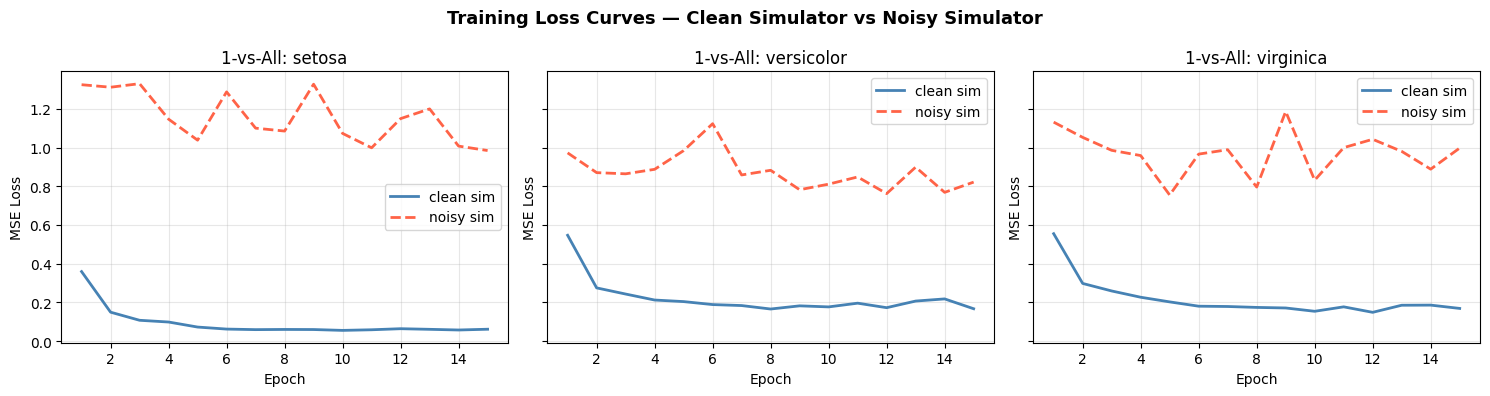

In [28]:
# 7.1 Loss curves — sim vs noisy training
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Training Loss Curves — Clean Simulator vs Noisy Simulator", fontsize=13, fontweight='bold')

for ax, class_name in zip(axes, CLASS_NAMES):
    ax.plot(range(1, len(sim_results[class_name]["loss_curve"]) + 1),
            sim_results[class_name]["loss_curve"],
            label='clean sim', linewidth=2, color='steelblue')
    ax.plot(range(1, len(hw_results[class_name]["loss_curve"]) + 1),
            hw_results[class_name]["loss_curve"],
            label='noisy sim', linewidth=2, color='tomato', linestyle='--')
    ax.set_title(f"1-vs-All: {class_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

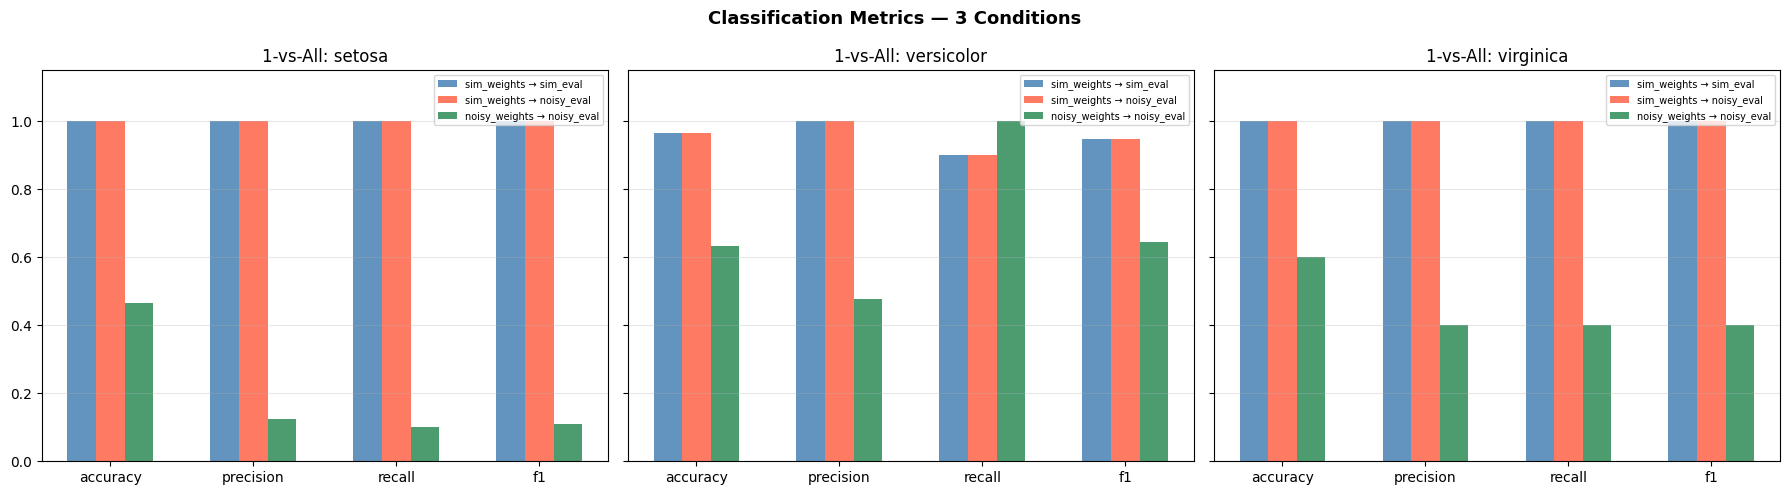

In [29]:
# 7.2 Metrics bar chart — 3 conditions per class
metric_cols = ["accuracy", "precision", "recall", "f1"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle("Classification Metrics — 3 Conditions", fontsize=13, fontweight='bold')

bar_w = 0.2
conditions = [
    ("sim_weights → sim_eval",   "steelblue", -bar_w),
    ("sim_weights → noisy_eval", "tomato",     0.0),
    ("noisy_weights → noisy_eval","seagreen",  bar_w),
]
x = np.arange(len(metric_cols))

for ax, class_name in zip(axes, CLASS_NAMES):
    for label, color, offset in conditions:
        row = metrics_df[(metrics_df["class"] == class_name) &
                         (metrics_df["condition"] == label)].iloc[0]
        vals = [row[m] for m in metric_cols]
        ax.bar(x + offset, vals, width=bar_w, label=label, color=color, alpha=0.85)

    ax.set_title(f"1-vs-All: {class_name}")
    ax.set_xticks(x)
    ax.set_xticklabels(metric_cols)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

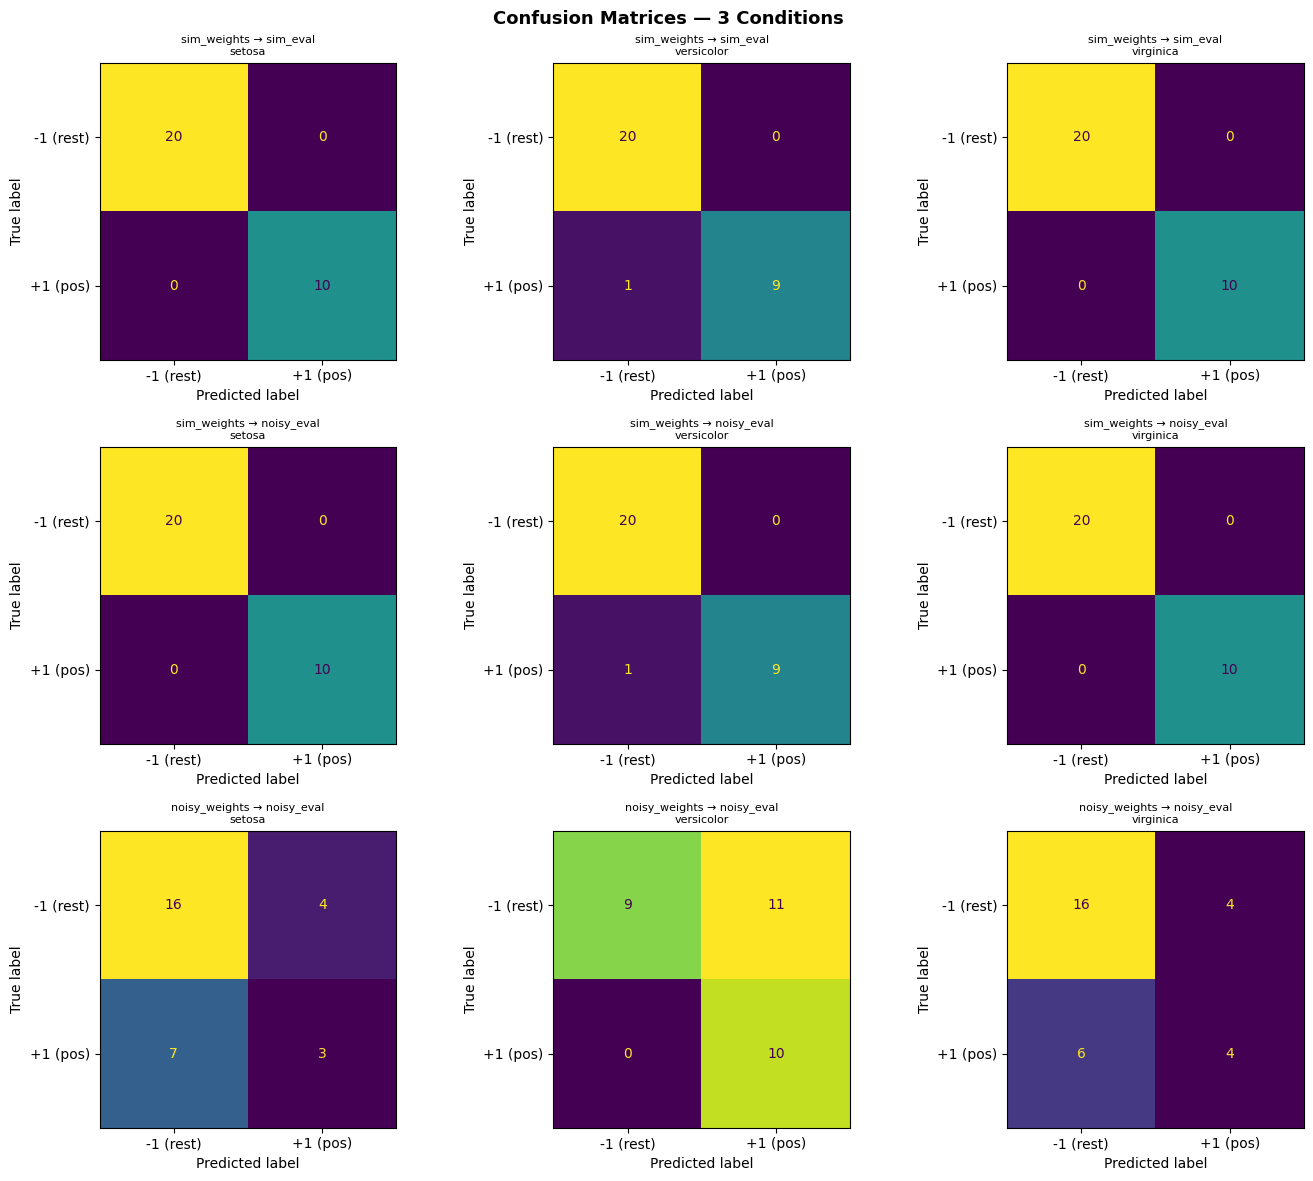

In [30]:
# 7.3 Confusion matrices — 3 rows × 3 cols
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle("Confusion Matrices — 3 Conditions", fontsize=13, fontweight='bold')

conditions_cm = [
    ("sim_weights → sim_eval",    sim_circuits, sim_results),
    ("sim_weights → noisy_eval",  hw_circuits,  sim_results),
    ("noisy_weights → noisy_eval",hw_circuits,  hw_results),
]

for col, class_name in enumerate(CLASS_NAMES):
    d = datasets[class_name]
    y_true = d["y_test"].astype(int)

    for row, (label, circuit_dict, result_dict) in enumerate(conditions_cm):
        y_pred = predict_binary(circuit_dict[class_name],
                                result_dict[class_name]["weights"],
                                d["X_test"])
        cm = confusion_matrix(y_true, y_pred, labels=[-1, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=["-1 (rest)", "+1 (pos)"])
        disp.plot(ax=axes[row][col], colorbar=False)
        axes[row][col].set_title(f"{label}\n{class_name}", fontsize=8)

plt.tight_layout()
plt.show()

With N_LAYERS=5 the circuit is deep enough that noise during evaluation is meaningful:
- If `sim_weights → noisy_eval` degrades noticeably vs `sim_weights → sim_eval`, the circuit noise is significant and anti-noise techniques on evaluation have room to help.
- `noisy_weights → noisy_eval` reflects the realistic hardware training scenario (SPSA optimiser, 512 shots).
- The SVM baseline tells us how much expressivity the quantum model actually adds.

**Anti-noise pipeline strategy:**
REM is applied first in all combined techniques because:
1. Readout error is the largest single error source on real hardware (~1–5% per qubit).
2. ZNE/PEC scale up gate noise — if readout error is not removed first, they amplify it too.
3. REM calibration is cheap (2^n_qubits circuits) and reusable across all inference calls.


# 8. Anti-Noise Techniques

In [31]:
from qiskit import QuantumCircuit
from qiskit import ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit.quantum_info import SparsePauliOp
from mitiq import zne, pec
from mitiq.zne.scaling import fold_gates_at_random, fold_global
from mitiq.zne.inference import RichardsonFactory, LinearFactory
import mthree


In [32]:
def build_qiskit_vqc(weights, inputs, n_qubits=N_QUBITS, n_layers=N_LAYERS):
    """
    Reconstruct the VQC as a native Qiskit circuit using the exact gate
    decomposition that PennyLane generates:
      - AngleEmbedding  → RY(x_i) on each qubit
      - StronglyEntanglingLayers → Rot(a,b,c) + CNOTs with range-based pattern
        range per layer l: (l % (n_qubits-1)) + 1
        For n_qubits=4, n_layers=5:
          layer 0: range=1 → CNOTs 0→1, 1→2, 2→3, 3→0
          layer 1: range=2 → CNOTs 0→2, 1→3, 2→0, 3→1
          layer 2: range=3 → CNOTs 0→3, 1→0, 2→1, 3→2
          layer 3: range=1 → CNOTs 0→1, 1→2, 2→3, 3→0  (repeats)
          layer 4: range=2 → CNOTs 0→2, 1→3, 2→0, 3→1
    Weights shape: (n_layers, n_qubits, 3) — matches PennyLane's weight_shape.
    """
    qc = QuantumCircuit(n_qubits)
    w  = np.array(weights).reshape(n_layers, n_qubits, 3)

    ranges = [(l % (n_qubits - 1)) + 1 for l in range(n_layers)]

    for layer_idx in range(n_layers):
        # AngleEmbedding — RY(x_i) on qubit i
        for qubit, angle in enumerate(inputs):
            qc.ry(float(angle), qubit)

        # Rot(a, b, c) = RZ(a) RY(b) RZ(c)
        for qubit in range(n_qubits):
            qc.rz(float(w[layer_idx, qubit, 0]), qubit)
            qc.ry(float(w[layer_idx, qubit, 1]), qubit)
            qc.rz(float(w[layer_idx, qubit, 2]), qubit)

        # CNOT entanglers
        r = ranges[layer_idx]
        for qubit in range(n_qubits):
            qc.cx(qubit, (qubit + r) % n_qubits)

    return qc


In [33]:
observable = SparsePauliOp("Z" + "I" * (N_QUBITS - 1))  # ⟨Z₀⟩

def noisy_executor(qc):
    """
    Run a Qiskit circuit on the noisy Aer backend and return ⟨Z₀⟩.
    mitiq calls this internally when applying noise-scaling transforms.
    Uses EstimatorV2 API (qiskit-aer >= 0.13).
    shots = SHOTS_HW (512) — enough for stable expectation values.
    """
    estimator = AerEstimator()
    estimator.options.noise_model = noise_model
    estimator.options.shots = SHOTS_HW
    pub    = (qc, observable)
    result = estimator.run([pub]).result()
    return float(result[0].data.evs)


In [34]:
# ── Baseline: noisy eval, no mitigation ─────────────────────────────────────
def predict_noisy_baseline(weights, X):
    """Noisy Aer evaluation without any mitigation. Lower bound."""
    scores = []
    for x in X:
        qc = build_qiskit_vqc(weights, x)
        scores.append(noisy_executor(qc))
    return np.where(np.array(scores) >= 0.0, 1, -1).astype(int)


# ── REM: Readout Error Mitigation (mthree) ────────────────────────────────────
# Applied FIRST in all combined pipelines because readout error is the
# dominant noise source and ZNE/PEC should operate on gate-error only.
def build_mem_mitigator(n_qubits=N_QUBITS, shots=SHOTS_HW):
    """
    Calibrate mthree on the noisy Aer backend.
    Runs 2^n_qubits calibration circuits (16 for 4 qubits) with `shots` each.
    The resulting calibration matrix maps ideal → noisy bitstring distributions;
    its pseudo-inverse is used to correct measurement counts at inference time.
    """
    backend_aer = AerSimulator(noise_model=noise_model)
    mit = mthree.M3Mitigation(backend_aer)
    mit.cals_from_system(range(n_qubits), shots=shots)
    return mit


def get_rem_corrected_expval(weights, x, mitigator, n_qubits=N_QUBITS):
    """
    Run one sample, apply REM, return ⟨Z₀⟩ from the corrected distribution.
    Separated so it can be reused inside ZNE+REM pipelines.
    Z₀ eigenvalue: +1 if qubit 0 = |0⟩, -1 if qubit 0 = |1⟩.
    In Qiskit bitstring ordering the rightmost character is qubit 0.
    """
    backend_aer = AerSimulator(noise_model=noise_model)
    qc = build_qiskit_vqc(weights, x)
    cr = ClassicalRegister(n_qubits, 'c')
    qc.add_register(cr)
    for i in range(n_qubits):
        qc.measure(i, cr[i])

    raw_counts = backend_aer.run(qc, shots=SHOTS_HW).result().get_counts()
    quasi_dist = mitigator.apply_correction(raw_counts, range(n_qubits))

    return sum(
        prob * (1 if bitstring[-1] == '0' else -1)
        for bitstring, prob in quasi_dist.items()
    )


def predict_rem(weights, X, mitigator):
    """REM-only prediction — no gate noise mitigation."""
    scores = [get_rem_corrected_expval(weights, x, mitigator) for x in X]
    return np.where(np.array(scores) >= 0.0, 1, -1).astype(int)


In [35]:
# ── ZNE: Zero Noise Extrapolation ───────────────────────────────────────────
def predict_zne(weights, X):
    """
    ZNE with global circuit folding (C → C·C†·C at scale 3) and
    Richardson extrapolation at scale factors [1, 2, 3].
    Amplifies the full circuit noise uniformly — simple but increases depth.
    """
    factory = RichardsonFactory(scale_factors=[1, 2, 3])
    scores  = []
    for x in X:
        qc = build_qiskit_vqc(weights, x)
        scores.append(zne.execute_with_zne(
            qc, executor=noisy_executor,
            factory=factory, scale_noise=fold_global,
        ))
    return np.where(np.array(scores) >= 0.0, 1, -1).astype(int)


def predict_digital_zne(weights, X):
    """
    Digital ZNE with random gate folding (G → G·G†·G) and Linear extrapolation.
    Hardware-friendly: amplifies noise at gate level, no pulse access needed.
    LinearFactory [1, 3] is more variance-stable than Richardson with noisy shots.
    """
    factory = LinearFactory(scale_factors=[1, 3])
    scores  = []
    for x in X:
        qc = build_qiskit_vqc(weights, x)
        scores.append(zne.execute_with_zne(
            qc, executor=noisy_executor,
            factory=factory, scale_noise=fold_gates_at_random,
        ))
    return np.where(np.array(scores) >= 0.0, 1, -1).astype(int)


# ── REM + ZNE combined ────────────────────────────────────────────────────────
# REM corrects readout errors first; ZNE then extrapolates over gate noise only.
def make_rem_executor(mitigator, n_qubits=N_QUBITS):
    """
    Wrap get_rem_corrected_expval as a stateless executor for mitiq.
    mitiq calls executor(qc) expecting a float — this closure captures the
    mitigator and applies REM before returning the expectation value.
    Note: the circuit passed by mitiq already has noise-scaled gates (folded);
    we add measurement registers on the fly each call.
    """
    backend_aer = AerSimulator(noise_model=noise_model)

    def executor(qc):
        qc_m = qc.copy()
        if qc_m.num_clbits == 0:
            cr = ClassicalRegister(n_qubits, 'c')
            qc_m.add_register(cr)
            for i in range(n_qubits):
                qc_m.measure(i, cr[i])
        raw = backend_aer.run(qc_m, shots=SHOTS_HW).result().get_counts()
        quasi = mitigator.apply_correction(raw, range(n_qubits))
        return sum(
            p * (1 if b[-1] == '0' else -1)
            for b, p in quasi.items()
        )
    return executor


def predict_rem_zne(weights, X, mitigator):
    """REM (readout) → ZNE (gate noise) combined pipeline."""
    rem_exec = make_rem_executor(mitigator)
    factory  = RichardsonFactory(scale_factors=[1, 2, 3])
    scores   = []
    for x in X:
        qc = build_qiskit_vqc(weights, x)
        scores.append(zne.execute_with_zne(
            qc, executor=rem_exec,
            factory=factory, scale_noise=fold_global,
        ))
    return np.where(np.array(scores) >= 0.0, 1, -1).astype(int)


def predict_rem_digital_zne(weights, X, mitigator):
    """REM (readout) → Digital ZNE (gate folding) combined pipeline."""
    rem_exec = make_rem_executor(mitigator)
    factory  = LinearFactory(scale_factors=[1, 3])
    scores   = []
    for x in X:
        qc = build_qiskit_vqc(weights, x)
        scores.append(zne.execute_with_zne(
            qc, executor=rem_exec,
            factory=factory, scale_noise=fold_gates_at_random,
        ))
    return np.where(np.array(scores) >= 0.0, 1, -1).astype(int)


# ── PEC: Probabilistic Error Cancellation ────────────────────────────────────
def predict_pec(weights, X, noise_level_pec, num_samples=100):
    """
    PEC with local depolarising noise representations.
    Models each gate's noise as depolarising channel and estimates ⟨Z₀⟩ via
    Monte Carlo sampling over quasi-probability circuit variants.
    num_samples=100 gives reasonable variance for a 30-sample test set.
    Fallback to noisy baseline if representation learning fails.
    """
    scores = []
    for x in X:
        qc = build_qiskit_vqc(weights, x)
        try:
            reps = pec.represent_operations_in_circuit_with_local_depolarizing_noise(
                qc, noise_level=noise_level_pec
            )
            scores.append(pec.execute_with_pec(
                qc, executor=noisy_executor,
                representations=reps, num_samples=num_samples,
            ))
        except Exception as e:
            print(f"  PEC fallback ({e.__class__.__name__}): using noisy baseline")
            scores.append(noisy_executor(qc))
    return np.where(np.array(scores) >= 0.0, 1, -1).astype(int)


In [36]:
# Calibrate REM mitigator once — reused by all REM-based techniques
print("Calibrating REM (mthree) mitigator...")
mem_mitigator = build_mem_mitigator()
print("REM calibration done.\n")

# Technique registry
# Each entry: name → lambda(weights, X) → binary predictions
techniques = {
    "baseline"        : lambda w, X: predict_noisy_baseline(w, X),
    "REM"             : lambda w, X: predict_rem(w, X, mem_mitigator),
    "ZNE"             : lambda w, X: predict_zne(w, X),
    "Digital_ZNE"     : lambda w, X: predict_digital_zne(w, X),
    "REM+ZNE"         : lambda w, X: predict_rem_zne(w, X, mem_mitigator),
    "REM+Digital_ZNE" : lambda w, X: predict_rem_digital_zne(w, X, mem_mitigator),
    "PEC"             : lambda w, X: predict_pec(w, X, noise_level_PEC),
}

mitigation_rows = []

for technique_name, predict_fn in techniques.items():
    print(f"\n{'─'*55}")
    print(f" Technique: {technique_name}")
    print(f"{'─'*55}")
    for class_name in CLASS_NAMES:
        d       = datasets[class_name]
        weights = hw_results[class_name]["weights"]   # noisy SPSA weights
        y_pred  = predict_fn(weights, d["X_test"])
        m       = compute_metrics(d["y_test"].astype(int), y_pred, class_name)
        m["technique"] = technique_name
        mitigation_rows.append(m)
        print(f"  {class_name:12s}  acc={m['accuracy']:.3f}  f1={m['f1']:.3f}")

mitigation_df = pd.DataFrame(mitigation_rows)[
    ["technique", "class", "accuracy", "precision", "recall", "f1"]
]

pd.set_option('display.float_format', '{:.3f}'.format)
print("\n" + "="*75)
print(" Anti-noise Techniques — Noisy Weights (SPSA, 512 shots)")
print("="*75)
print(mitigation_df.to_string(index=False))


Calibrating REM (mthree) mitigator...
REM calibration done.


───────────────────────────────────────────────────────
 Technique: baseline
───────────────────────────────────────────────────────
  setosa        acc=0.600  f1=0.625
  versicolor    acc=0.367  f1=0.296
  virginica     acc=0.300  f1=0.323

───────────────────────────────────────────────────────
 Technique: REM
───────────────────────────────────────────────────────
  setosa        acc=0.333  f1=0.333
  versicolor    acc=0.467  f1=0.385
  virginica     acc=0.200  f1=0.250

───────────────────────────────────────────────────────
 Technique: ZNE
───────────────────────────────────────────────────────
  setosa        acc=0.600  f1=0.625
  versicolor    acc=0.367  f1=0.296
  virginica     acc=0.300  f1=0.323

───────────────────────────────────────────────────────
 Technique: Digital_ZNE
───────────────────────────────────────────────────────
  setosa        acc=0.600  f1=0.625
  versicolor    acc=0.367  f1=0.296
  virginica   

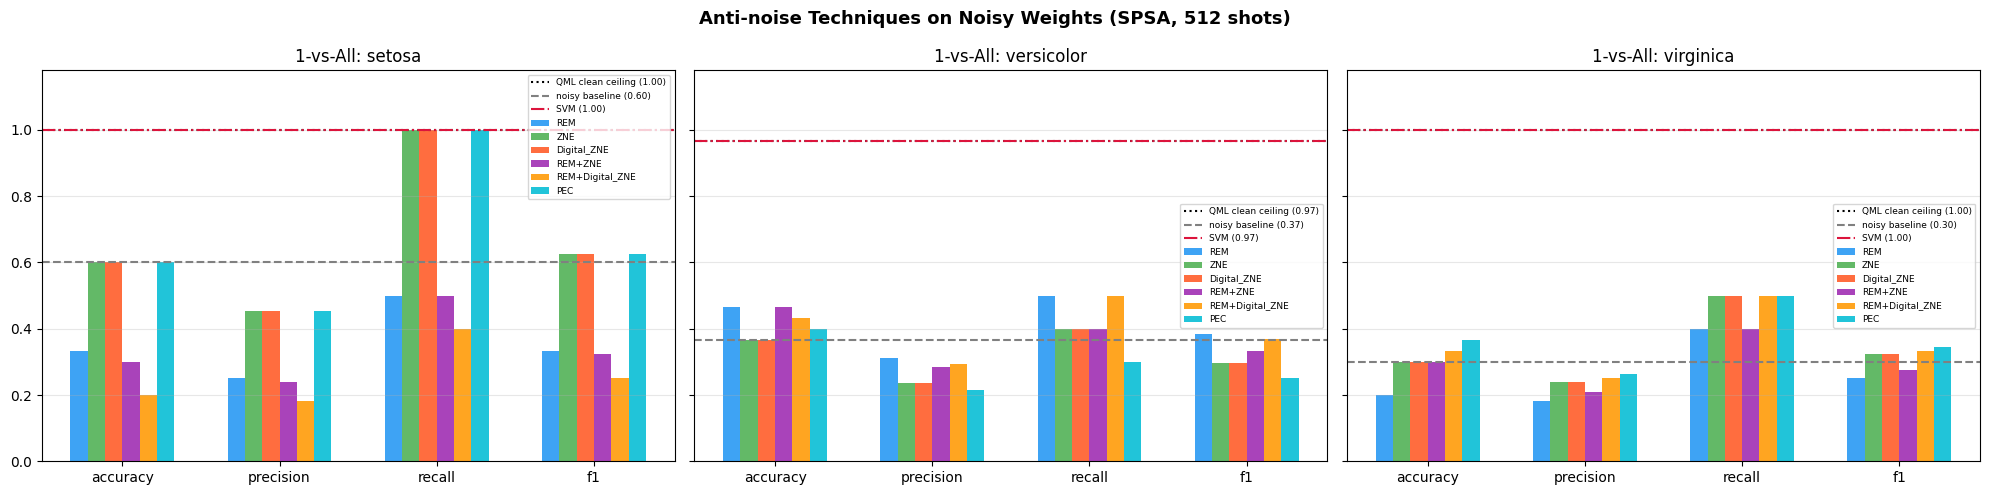

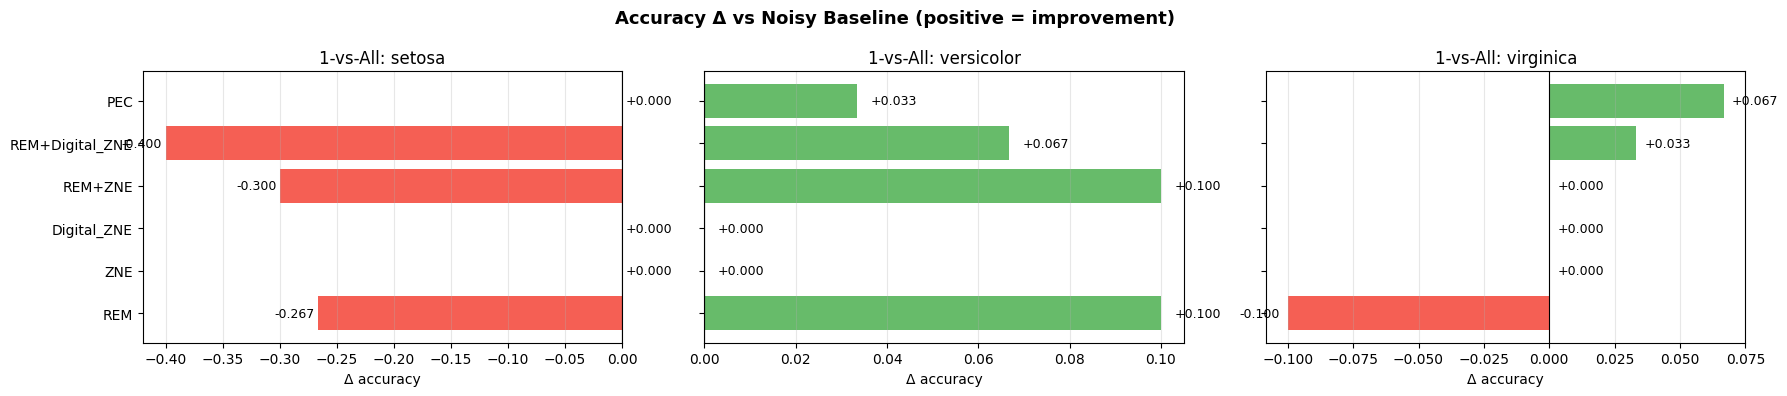

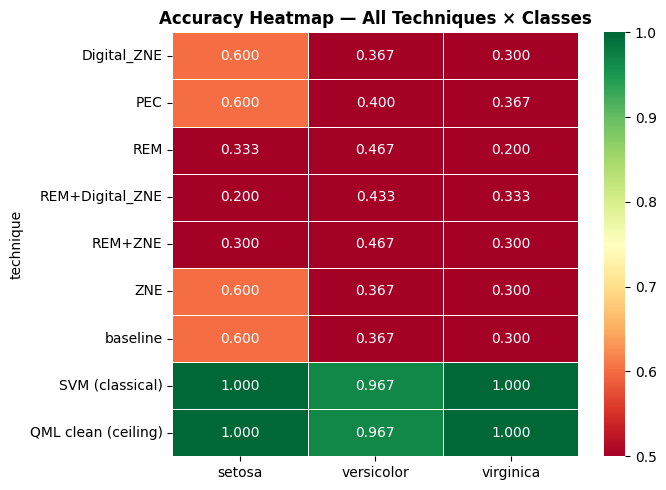

In [37]:
# ── 8.1 Bar chart: anti-noise techniques vs baselines ────────────────────────
metric_cols     = ["accuracy", "precision", "recall", "f1"]
technique_names = [t for t in techniques.keys() if t != "baseline"]
palette = ["#2196F3", "#4CAF50", "#FF5722", "#9C27B0", "#FF9800", "#00BCD4"]
bar_w   = 0.11
x       = np.arange(len(metric_cols))

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
fig.suptitle("Anti-noise Techniques on Noisy Weights (SPSA, 512 shots)",
             fontsize=13, fontweight='bold')

for ax, class_name in zip(axes, CLASS_NAMES):
    n = len(technique_names)
    for i, (tech, color) in enumerate(zip(technique_names, palette)):
        offset = (i - n / 2) * bar_w + bar_w / 2
        row = mitigation_df[
            (mitigation_df["class"] == class_name) &
            (mitigation_df["technique"] == tech)
        ].iloc[0]
        vals = [row[m] for m in metric_cols]
        ax.bar(x + offset, vals, width=bar_w, label=tech, color=color, alpha=0.87)

    # Reference lines
    clean_acc = metrics_df[
        (metrics_df["class"] == class_name) &
        (metrics_df["condition"] == "sim_weights → sim_eval")
    ]["accuracy"].values[0]
    ax.axhline(clean_acc, color='black', linestyle=':', linewidth=1.5,
               label=f'QML clean ceiling ({clean_acc:.2f})')

    baseline_acc = mitigation_df[
        (mitigation_df["class"] == class_name) &
        (mitigation_df["technique"] == "baseline")
    ]["accuracy"].values[0]
    ax.axhline(baseline_acc, color='gray', linestyle='--', linewidth=1.5,
               label=f'noisy baseline ({baseline_acc:.2f})')

    # SVM reference line
    svm_acc = svm_df[svm_df["class"] == class_name]["accuracy"].values[0]
    ax.axhline(svm_acc, color='crimson', linestyle='-.', linewidth=1.5,
               label=f'SVM ({svm_acc:.2f})')

    ax.set_title(f"1-vs-All: {class_name}")
    ax.set_xticks(x)
    ax.set_xticklabels(metric_cols)
    ax.set_ylim(0, 1.18)
    ax.legend(fontsize=6.5)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# ── 8.2 Accuracy delta vs noisy baseline ─────────────────────────────────────
# Shows how much each technique gains (positive) or loses (negative) vs no mitigation.
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
fig.suptitle("Accuracy Δ vs Noisy Baseline (positive = improvement)",
             fontsize=13, fontweight='bold')

for ax, class_name in zip(axes, CLASS_NAMES):
    base_acc = mitigation_df[
        (mitigation_df["class"] == class_name) &
        (mitigation_df["technique"] == "baseline")
    ]["accuracy"].values[0]

    techs  = [t for t in techniques.keys() if t != "baseline"]
    deltas = []
    for t in techs:
        acc = mitigation_df[
            (mitigation_df["class"] == class_name) &
            (mitigation_df["technique"] == t)
        ]["accuracy"].values[0]
        deltas.append(acc - base_acc)

    colors_bar = ["#4CAF50" if d >= 0 else "#F44336" for d in deltas]
    bars = ax.barh(techs, deltas, color=colors_bar, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"1-vs-All: {class_name}")
    ax.set_xlabel("Δ accuracy")
    ax.grid(axis='x', alpha=0.3)
    for bar, d in zip(bars, deltas):
        ax.text(d + (0.003 if d >= 0 else -0.003), bar.get_y() + bar.get_height() / 2,
                f"{d:+.3f}", va='center', ha='left' if d >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()


# ── 8.3 Summary heatmap: accuracy across all techniques × classes ─────────────
pivot = mitigation_df.pivot(index="technique", columns="class", values="accuracy")

# Add SVM and QML clean rows for full context
for class_name in CLASS_NAMES:
    svm_acc = svm_df[svm_df["class"] == class_name]["accuracy"].values[0]
    clean_acc = metrics_df[
        (metrics_df["class"] == class_name) &
        (metrics_df["condition"] == "sim_weights → sim_eval")
    ]["accuracy"].values[0]

extra_rows = {}
for class_name in CLASS_NAMES:
    if "SVM (classical)" not in extra_rows:
        extra_rows["SVM (classical)"] = {}
    extra_rows["SVM (classical)"][class_name] = svm_df[
        svm_df["class"] == class_name]["accuracy"].values[0]
    if "QML clean (ceiling)" not in extra_rows:
        extra_rows["QML clean (ceiling)"] = {}
    extra_rows["QML clean (ceiling)"][class_name] = metrics_df[
        (metrics_df["class"] == class_name) &
        (metrics_df["condition"] == "sim_weights → sim_eval")
    ]["accuracy"].values[0]

extra_df = pd.DataFrame(extra_rows).T
extra_df.index.name = "technique"
pivot = pd.concat([pivot, extra_df])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot.astype(float), annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0.5, vmax=1.0, ax=ax, linewidths=0.5)
ax.set_title("Accuracy Heatmap — All Techniques × Classes", fontweight='bold')
plt.tight_layout()
plt.show()
